In [ ]:
# Figure 9 (?) Persistence & Restoration Strategy Maps

In [ ]:
# --------------------------------------------------------------------------------------
# NOTEBOOK: Figure X — Persistence → Restoration Strategy Maps (4-panel)
#
# This notebook builds a single, integrated 4-panel figure:
#   (a) Histogram of % years underperforming (color-coded by priority bins)
#   (b) Empirical CDF of the same metric (with shaded regions + threshold guides)
#   (c) DML-scale map of wetlands colored by priority bin (centroids or polygons)
#   (d) Zoom-in map showing individual wetlands and color-coding at decision scale
#
# It uses your existing inputs:
#   - LONG_CSV:  per-wetland probability long format (prob for tau=0 gives % years)
#   - WETLANDS_GPKG: polygons in EPSG:5070
#   - DML_BOUNDARY_SHP: DML boundary in EPSG:5070
#
# Output:
#   - Figure_Persistence_RestorationPriorities_4panel.(png/jpg)
#
# Kimberly Van Meter
# --------------------------------------------------------------------------------------


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde


In [8]:
import os
# ------------------------------------------------------------
# PATHS (use your existing conventions)
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Inputs
LONG_CSV = OUT_DIR / "UAI_per_wetland_probs_nocrop_long.csv"

WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

DML_BOUNDARY_SHP = PROJECT_ROOT / "DML_2023" / "Shapefiles" / "dml_boundaries_5070.shp"

# Outputs
FIG_PNG = OUT_DIR / "Figure_Persistence_RestorationPriorities_4panel.png"
FIG_JPG = OUT_DIR / "Figure_Persistence_RestorationPriorities_4panel.jpg"

# ID fields
ID_COL_LONG = "label"      # long CSV
ID_COL_GPKG = "Index"      # wetlands gpkg

TARGET_CRS = "EPSG:5070"


In [9]:
# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

# Use tau=0 => prob = fraction of years with UAI > 0
TAU0 = 0.0

# Priority thresholds (percent of years with underperformance)
T1 = 50.0
T2 = 85.0

# Histogram bins
BINS = np.linspace(0, 100, 21)

# Category colors (choose/adjust as you like)
# (kept in a coherent blue ramp; readable in print)
COLORS = {
    "Climate-contingent (<50%)": "#BFD3E6",
    "Intermittent (50–85%)":     "#6BAED6",
    "Persistent (≥85%)":         "#2171B5",
}

# Map styling
PLOT_POLYGONS = False   # True plots polygons (heavier); False plots centroids (fast/clear)
POINT_SIZE = 1.2        # for centroid plotting (tune)
POINT_ALPHA = 0.85

# Zoom window (auto or manual)
AUTO_ZOOM = True
ZOOM_HALF_WIDTH_M = 35_000   # half-width of zoom window (meters): ~70 km wide window
ZOOM_HALF_HEIGHT_M = 35_000

# KDE settings for auto zoom
ZOOM_KDE_BW_MULT = 0.8
ZOOM_KDE_GRID_N = 250  # grid resolution for finding KDE max


In [10]:
# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def full_box(ax, lw=1.0):
    """Make full bounding box visible with consistent linewidth."""
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(lw)

def compute_underperf_percent(df_long: pd.DataFrame, tau0: float, id_col: str) -> pd.DataFrame:
    """
    From the long CSV, pull tau=0 probabilities and convert to % underperformance.
    Returns: DataFrame with columns [id_col, underperf_pct]
    """
    sub = df_long[df_long["threshold"] == tau0].copy()
    if sub.empty:
        raise ValueError(f"No rows found with threshold == {tau0}. Check LONG_CSV contents.")

    if "prob" not in sub.columns:
        raise KeyError("Expected column 'prob' in long CSV.")

    out = sub[[id_col, "prob"]].dropna()
    out["underperf_pct"] = out["prob"] * 100.0
    return out[[id_col, "underperf_pct"]]

def assign_priority_bin(pct: float, t1: float, t2: float) -> str:
    """Assign bin label based on percent underperformance."""
    if pct < t1:
        return "Climate-contingent (<50%)"
    elif pct < t2:
        return "Intermittent (50–85%)"
    else:
        return "Persistent (≥85%)"

def add_threshold_guides_hist(ax, t1: float, t2: float):
    """Add vertical threshold lines to histogram."""
    ax.axvline(t1, color="0.5", linestyle="--", linewidth=1.0)
    ax.axvline(t2, color="0.5", linestyle="--", linewidth=1.0)

def add_threshold_guides_cdf(ax, vals_sorted, cdf, t1: float, t2: float):
    """Add guide lines at thresholds for the CDF panel."""
    cdf_t1 = np.interp(t1, vals_sorted, cdf)
    cdf_t2 = np.interp(t2, vals_sorted, cdf)

    # Vertical and horizontal guides
    ax.axvline(t1, ymin=0, ymax=cdf_t1, color="0.5", linestyle="--", linewidth=1.0)
    ax.plot([0, t1], [cdf_t1, cdf_t1], color="0.5", linestyle="--", linewidth=1.0)

    ax.axvline(t2, ymin=0, ymax=cdf_t2, color="0.5", linestyle="--", linewidth=1.0)
    ax.plot([0, t2], [cdf_t2, cdf_t2], color="0.5", linestyle="--", linewidth=1.0)

    return cdf_t1, cdf_t2

def auto_zoom_bounds(gdf_points: gpd.GeoDataFrame,
                     bw_mult: float = 0.8,
                     grid_n: int = 250,
                     half_w: float = 35_000,
                     half_h: float = 35_000):
    """
    Find a good zoom window automatically by locating the KDE maximum for
    the 'Persistent (≥85%)' points (or provided points).
    Returns (xmin, xmax, ymin, ymax).
    """
    if gdf_points.empty:
        raise ValueError("No points provided for auto zoom. Consider AUTO_ZOOM=False with manual bounds.")

    xs = gdf_points.geometry.x.values
    ys = gdf_points.geometry.y.values
    xy = np.vstack([xs, ys])

    kde = gaussian_kde(xy)
    kde.set_bandwidth(kde.factor * bw_mult)

    xmin, ymin, xmax, ymax = gdf_points.total_bounds
    # modest padding
    pad = 10_000
    xmin -= pad; ymin -= pad; xmax += pad; ymax += pad

    xgrid = np.linspace(xmin, xmax, grid_n)
    ygrid = np.linspace(ymin, ymax, grid_n)
    X, Y = np.meshgrid(xgrid, ygrid)
    pos = np.vstack([X.ravel(), Y.ravel()])

    Z = kde(pos).reshape(X.shape)
    i, j = np.unravel_index(np.argmax(Z), Z.shape)
    x0 = X[i, j]
    y0 = Y[i, j]

    return (x0 - half_w, x0 + half_w, y0 - half_h, y0 + half_h)


In [12]:
# ------------------------------------------------------------
# LOAD + PREP DATA
# ------------------------------------------------------------

# 1) Long CSV -> underperformance percent
df_long = pd.read_csv(LONG_CSV)
need = {ID_COL_LONG, "threshold", "prob"}
missing = need.difference(df_long.columns)
if missing:
    raise KeyError(f"Missing columns in LONG_CSV: {missing}")

df_pct = compute_underperf_percent(df_long, tau0=TAU0, id_col=ID_COL_LONG)
df_pct["priority_bin"] = df_pct["underperf_pct"].apply(lambda x: assign_priority_bin(x, T1, T2))

print("[INFO] Underperformance % computed:")
print(df_pct["priority_bin"].value_counts())

# 2) Wetlands polygons
gdf_wet = gpd.read_file(WETLANDS_GPKG)
if ID_COL_GPKG not in gdf_wet.columns:
    raise KeyError(f"'{ID_COL_GPKG}' not in wetlands GPKG columns: {list(gdf_wet.columns)}")

if gdf_wet.crs is None:
    print("[WARN] Wetlands GPKG has no CRS; assuming EPSG:5070.")
    gdf_wet = gdf_wet.set_crs(TARGET_CRS)
elif str(gdf_wet.crs) != TARGET_CRS:
    gdf_wet = gdf_wet.to_crs(TARGET_CRS)

# 3) DML boundary
gdf_dml = gpd.read_file(DML_BOUNDARY_SHP)
if gdf_dml.crs is None:
    gdf_dml = gdf_dml.set_crs(TARGET_CRS)
elif str(gdf_dml.crs) != TARGET_CRS:
    gdf_dml = gdf_dml.to_crs(TARGET_CRS)

# 4) Merge wetlands with underperformance metric (Index <-> label)
gdf_join = gdf_wet.merge(
    df_pct[[ID_COL_LONG, "underperf_pct", "priority_bin"]],
    left_on=ID_COL_GPKG,
    right_on=ID_COL_LONG,
    how="inner",
)

print(f"[INFO] Wetlands with underperf metric: {len(gdf_join)}")

if gdf_join.empty:
    raise ValueError("Merge produced 0 rows — check ID fields and inputs.")


[INFO] Underperformance % computed:
priority_bin
Intermittent (50–85%)        85885
Climate-contingent (<50%)    39639
Persistent (≥85%)            13010
Name: count, dtype: int64
[INFO] Wetlands with underperf metric: 135204


In [13]:
# ------------------------------------------------------------
# COMPUTE ZOOM BOUNDS (optional)
# ------------------------------------------------------------

if AUTO_ZOOM:
    # Use persistent sites to locate densest cluster for zoom
    gdf_persist = gdf_join[gdf_join["priority_bin"] == "Persistent (≥85%)"].copy()
    if gdf_persist.empty:
        print("[WARN] No persistent sites found; auto-zoom will use all sites.")
        gdf_persist = gdf_join.copy()

    # Use centroids for KDE search even if we plot polygons
    pts = gdf_persist.copy()
    pts["geometry"] = pts.geometry.centroid

    xmin_z, xmax_z, ymin_z, ymax_z = auto_zoom_bounds(
        pts,
        bw_mult=ZOOM_KDE_BW_MULT,
        grid_n=ZOOM_KDE_GRID_N,
        half_w=ZOOM_HALF_WIDTH_M,
        half_h=ZOOM_HALF_HEIGHT_M,
    )
else:
    # Manual bounds example (fill these in if you want manual control)
    # xmin_z, xmax_z, ymin_z, ymax_z = (x0-35000, x0+35000, y0-35000, y0+35000)
    raise NotImplementedError("Set AUTO_ZOOM=True or define manual bounds.")

print("[INFO] Zoom bounds (m):", xmin_z, xmax_z, ymin_z, ymax_z)


[INFO] Zoom bounds (m): 168173.63488037797 238173.63488037797 2140233.8279392244 2210233.8279392244


[SAVED] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_Persistence_RestorationPriorities_4panel.png
[SAVED] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_Persistence_RestorationPriorities_4panel.jpg


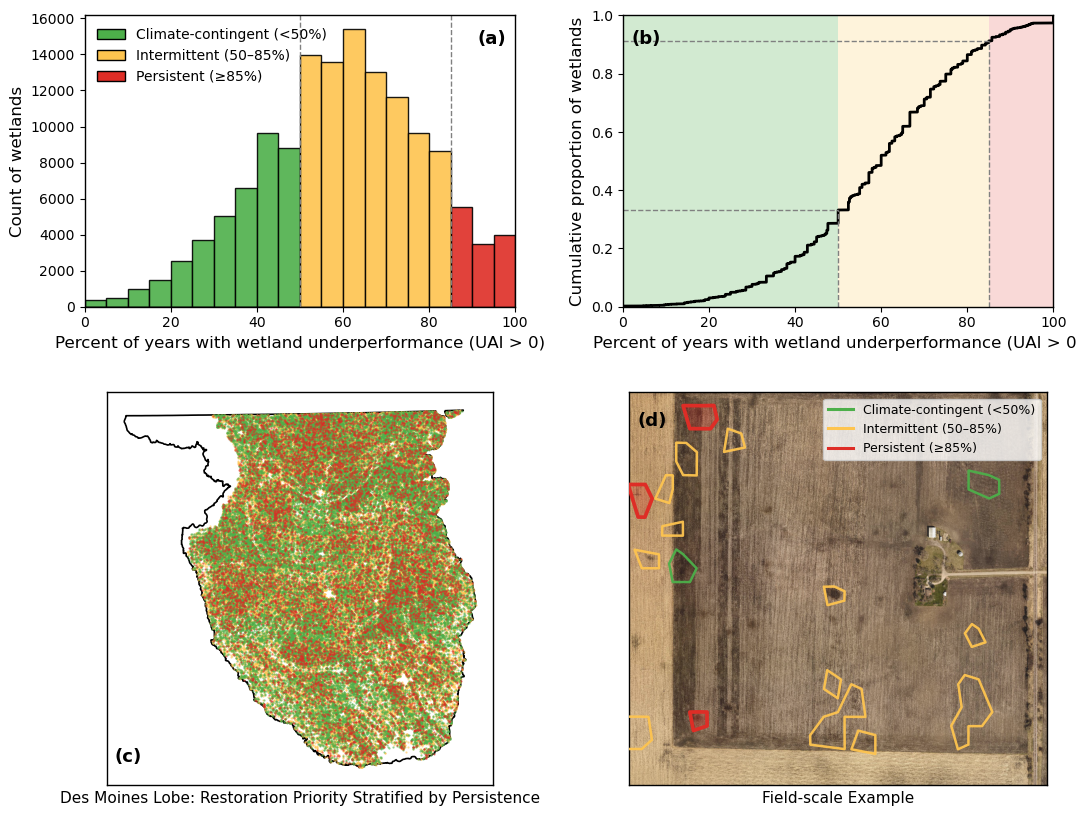

In [14]:
# build figure, try different colors: # ------------------------------------------------------------
# BUILD FIGURE
# ------------------------------------------------------------

import contextily as ctx
from pyproj import Transformer
from matplotlib.lines import Line2D


POINT_SIZE = 0.35
POINT_ALPHA = 0.55

## Red/Yellow/Green stoplight scheme (very legible, very dramatic)
COLORS = {
    "Climate-contingent (<50%)": "#4DAF4A",  # green (CB-safe)
    "Intermittent (50–85%)":     "#FEC44F",  # yellow/orange (medium)
    "Persistent (≥85%)":         "#DE2D26",  # red (highest priority)
}


# Values for histogram/CDF
vals_pct = df_pct["underperf_pct"].dropna().values
vals_sorted = np.sort(vals_pct)
n = vals_sorted.size
cdf = np.arange(1, n + 1) / n

# Category masks (for hist coloring)
cat_order = [
    "Climate-contingent (<50%)",
    "Intermittent (50–85%)",
    "Persistent (≥85%)",
]

CAT_ORDER_MAP = [
    "Intermittent (50–85%)",
    "Climate-contingent (<50%)",
    "Persistent (≥85%)",
]


# Figure layout: 2 rows x 2 cols
#   (a) hist, (b) cdf
#   (c) DML map, (d) zoom map
fig = plt.figure(figsize=(12.5, 10.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.35], wspace=0.25, hspace=0.25)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ------------------------------------------------------------
# (a) HISTOGRAM — color-coded by bin
# ------------------------------------------------------------
# Plot hist separately by category so bars are colored by bin
for lab in cat_order:
    m = (df_pct["priority_bin"] == lab)
    ax_a.hist(
        df_pct.loc[m, "underperf_pct"].values,
        bins=BINS,
        color=COLORS[lab],
        edgecolor="black",
        alpha=0.9,
        label=lab,
    )

add_threshold_guides_hist(ax_a, T1, T2)
ax_a.set_xlim(0, 100)
ax_a.set_xlabel("Percent of years with wetland underperformance (UAI > 0)", fontsize=12)
ax_a.set_ylabel("Count of wetlands", fontsize=12)
ax_a.text(
    0.98, 0.95, "(a)",
    transform=ax_a.transAxes,
    fontsize=13,
    fontweight="bold",
    va="top",
    ha="right",
)
full_box(ax_a, lw=1.0)

# Legend as patches (cleaner)
legend_patches = [Patch(facecolor=COLORS[k], edgecolor="black", label=k) for k in cat_order]
ax_a.legend(handles=legend_patches, frameon=False, fontsize=10, loc="upper left")

# ------------------------------------------------------------
# (b) CDF — shaded by bin + guides
# ------------------------------------------------------------
ax_b.plot(vals_sorted, cdf, color="black", linewidth=2.0)

# Shade the CDF background regions by thresholds for visual categorization
ax_b.axvspan(0, T1, color=COLORS["Climate-contingent (<50%)"], alpha=0.25, lw=0)
ax_b.axvspan(T1, T2, color=COLORS["Intermittent (50–85%)"], alpha=0.20, lw=0)
ax_b.axvspan(T2, 100, color=COLORS["Persistent (≥85%)"], alpha=0.18, lw=0)

cdf_t1, cdf_t2 = add_threshold_guides_cdf(ax_b, vals_sorted, cdf, T1, T2)

ax_b.set_xlim(0, 100)
ax_b.set_ylim(0, 1)
ax_b.set_xlabel("Percent of years with wetland underperformance (UAI > 0)", fontsize=12, labelpad=4)
ax_b.set_ylabel("Cumulative proportion of wetlands", fontsize=12)
ax_b.text(0.02, 0.95, "(b)", transform=ax_b.transAxes, fontsize=13, fontweight="bold", va="top")
full_box(ax_b, lw=1.0)

# ------------------------------------------------------------
# (c) DML-scale map — wetlands colored by bin
# ------------------------------------------------------------
# Boundary
gdf_dml.boundary.plot(ax=ax_c, color="black", linewidth=1.2, zorder=2)

# Plot wetlands (centroids or polygons)
if PLOT_POLYGONS:
    for lab in CAT_ORDER_MAP:
        gdf_join[gdf_join["priority_bin"] == lab].plot(
            ax=ax_c,
            color=COLORS[lab],
            linewidth=0,
            alpha=0.85,
            zorder=3,
        )
else:
    pts_all = gdf_join.copy()
    pts_all["geometry"] = pts_all.geometry.centroid
    for lab in CAT_ORDER_MAP:
        pts_all[pts_all["priority_bin"] == lab].plot(
            ax=ax_c,
            color=COLORS[lab],
            markersize=POINT_SIZE,
            alpha=POINT_ALPHA,
            zorder=3,
        )

ax_c.set_aspect("equal")
ax_c.set_xticks([]); ax_c.set_yticks([])
ax_c.set_xlabel("Des Moines Lobe: Restoration Priority Stratified by Persistence", fontsize=11)
ax_c.text(
    0.02, 0.05, "(c)",
    transform=ax_c.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom",
    ha="left",
)
full_box(ax_c, lw=1.0)

# ------------------------------------------------------------
# (d) VERY tight zoom — satellite underlay + WETLAND POLYGON BOUNDARIES (all 3 classes)
# Drop-in block for your 4-panel figure script.
#
# Assumes you already have:
#   - gdf_join: wetlands GeoDataFrame in EPSG:5070 with column "priority_bin"
#   - COLORS: dict mapping priority_bin -> color
#   - cat_order: list of 3 labels (stats order is fine)
#   - ax_d: matplotlib axis for panel (d)
#   - full_box(ax, lw=...): your helper
#
# Requires:
#   pip install contextily pyproj
# ------------------------------------------------------------

# -----------------------------
# USER TUNABLES (panel d only)
# -----------------------------
ZOOM_HALF_M = 750            # 750 m half-width => 1.5 km wide window (tight field scale)
TILE_ZOOM = 17               # 16–18; higher = more detailed imagery
BASEMAP_ALPHA = 0.90         # imagery strength
OUTLINE_LW = 1.25            # polygon outline width
OUTLINE_ALPHA = 0.95         # polygon outline alpha

# If you want a subtle fill, set to e.g. 0.12; for outline-only keep 0.0
FILL_ALPHA = 0.00

# Plot order (controls which class sits "on top")
CAT_ORDER_POLY = [
    "Climate-contingent (<50%)",
    "Intermittent (50–85%)",
    "Persistent (≥85%)",      # last so it sits on top
]

# Optional: make an exemplar zoom centered on a persistent wetland
RANDOM_STATE = 42

# -----------------------------
# 1) Pick an exemplar wetland to center the zoom
# -----------------------------
seed = gdf_join[gdf_join["priority_bin"] == "Persistent (≥85%)"]
if seed.empty:
    seed = gdf_join

seed = seed.sample(1, random_state=RANDOM_STATE)
cent = seed.geometry.centroid.iloc[0]
x0, y0 = cent.x, cent.y

# Zoom bounds in EPSG:5070
xmin_z = x0 - ZOOM_HALF_M
xmax_z = x0 + ZOOM_HALF_M
ymin_z = y0 - ZOOM_HALF_M
ymax_z = y0 + ZOOM_HALF_M

# -----------------------------
# 2) Subset wetlands to zoom window (still in EPSG:5070)
# -----------------------------
gdf_zoom = gdf_join.cx[xmin_z:xmax_z, ymin_z:ymax_z].copy()

# Safety check: if too few polygons, expand window slightly
if len(gdf_zoom) < 10:
    ZOOM_HALF_M2 = int(ZOOM_HALF_M * 1.5)
    xmin_z = x0 - ZOOM_HALF_M2
    xmax_z = x0 + ZOOM_HALF_M2
    ymin_z = y0 - ZOOM_HALF_M2
    ymax_z = y0 + ZOOM_HALF_M2
    gdf_zoom = gdf_join.cx[xmin_z:xmax_z, ymin_z:ymax_z].copy()

    # ------------------------------------------------------------
# Tighten zoom to top-right quadrant of current window
# ------------------------------------------------------------

# ------------------------------------------------------------
# Directional expansion toward top-right (keeps focus, grows window)
# ------------------------------------------------------------

EXPAND = 0.1   # try 0.25–0.45

dx = xmax_z - xmin_z
dy = ymax_z - ymin_z

xmin_z = xmin_z + (0.5 - EXPAND) * dx
ymin_z = ymin_z + (0.5 - EXPAND) * dy

# Re-subset after adjusting bounds
gdf_zoom = gdf_join.cx[xmin_z:xmax_z, ymin_z:ymax_z].copy()
gdf_zoom_3857 = gdf_zoom.to_crs(epsg=3857)


# keep xmax/ymax fixed so we grow "down-left" into the field
# xmax_z, ymax_z unchanged


# -----------------------------
# 3) Reproject panel (d) layers to Web Mercator (EPSG:3857) for satellite tiles
# -----------------------------
gdf_zoom_3857 = gdf_zoom.to_crs(epsg=3857)

tf = Transformer.from_crs(5070, 3857, always_xy=True)
xmin_m, ymin_m = tf.transform(xmin_z, ymin_z)
xmax_m, ymax_m = tf.transform(xmax_z, ymax_z)

# -----------------------------
# 4) Draw satellite underlay (Esri World Imagery)
# -----------------------------
img, ext = ctx.bounds2img(
    xmin_m, ymin_m, xmax_m, ymax_m,
    source=ctx.providers.Esri.WorldImagery,
    ll=False,
    zoom=TILE_ZOOM,
)

ax_d.imshow(
    img,
    extent=ext,
    alpha=BASEMAP_ALPHA,
    zorder=1,
)

# -----------------------------
# Plot wetland polygon boundaries with emphasis on persistent class
# -----------------------------

OUTLINE_LW_BASE = 1.8     # thicker than before
OUTLINE_LW_PERSIST = 2.6 # extra emphasis
FILL_ALPHA_PERSIST = 0.25  # light interior fill for persistent only

for lab in CAT_ORDER_POLY:
    sub = gdf_zoom_3857[gdf_zoom_3857["priority_bin"] == lab]
    if sub.empty:
        continue

    if lab == "Persistent (≥85%)":
        # Filled + thick outline
        sub.plot(
            ax=ax_d,
            facecolor=COLORS[lab],
            edgecolor=COLORS[lab],
            linewidth=OUTLINE_LW_PERSIST,
            alpha=FILL_ALPHA_PERSIST,
            zorder=4,
        )
        # redraw outline crisp on top
        sub.plot(
            ax=ax_d,
            facecolor="none",
            edgecolor=COLORS[lab],
            linewidth=OUTLINE_LW_PERSIST,
            alpha=1.0,
            zorder=5,
        )
    else:
        # Outline-only for other classes
        sub.plot(
            ax=ax_d,
            facecolor="none",
            edgecolor=COLORS[lab],
            linewidth=OUTLINE_LW_BASE,
            alpha=0.95,
            zorder=3,
        )

# -----------------------------
# 6) Formatting / labels
# -----------------------------
ax_d.set_xlim(xmin_m, xmax_m)
ax_d.set_ylim(ymin_m, ymax_m)
ax_d.set_aspect("equal")
ax_d.set_xticks([]); ax_d.set_yticks([])
ax_d.text(
    0.02, 0.95, "(d)",
    transform=ax_d.transAxes,
    fontsize=13,
    fontweight="bold",
    va="top",
)

# Optional legend (outlines)
legend_handles = [
    Line2D([0], [0], color=COLORS[k], lw=2.2, label=k)
    for k in CAT_ORDER_POLY
]
ax_d.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    fontsize=9,
)

ax_d.set_xlabel(
    "Field-scale Example",
    fontsize=11,
)

full_box(ax_d, lw=1.0)

# ------------------------------------------------------------
# FINAL LAYOUT + SAVE
# ------------------------------------------------------------
# Important: call tight_layout once at the end, AFTER all axes are drawn.

plt.tight_layout()

# If you already defined these paths earlier, keep them.
# Otherwise define them here:
# FIG_PNG = OUT_DIR / "Figure_Persistence_RestorationPriorities_4panel.png"
# FIG_JPG = OUT_DIR / "Figure_Persistence_RestorationPriorities_4panel.jpg"

fig.savefig(FIG_PNG, dpi=300, bbox_inches="tight")
fig.savefig(FIG_JPG, dpi=300, bbox_inches="tight")
print(f"[SAVED] {FIG_PNG}")
print(f"[SAVED] {FIG_JPG}")

plt.show()




In [15]:
print("Columns:", list(gdf_join.columns))
print("Index name:", gdf_join.index.name)
print(gdf_join.head(2))


Columns: ['Index', 'area_m2', 'perim_m', 'cluster', 'touch', 'ints_ct', 'GIW', 'dist_str_m', 'dist_NN_m', 'agri', 'hydric', 'pwsl', 'drain', 'cwi_cov', 'HUC8_FILE', 'geometry', 'label', 'underperf_pct', 'priority_bin']
Index name: None
   Index  area_m2  perim_m  cluster  touch  ints_ct  GIW  dist_str_m  \
0  54684   2224.5    229.0       52      0      0.0  1.0       211.0   
1  54670   1176.0    193.0       52      0      0.0  1.0       318.0   

   dist_NN_m  agri  hydric  pwsl  drain  cwi_cov HUC8_FILE  \
0      618.0     1     1.0  95.0    6.0      NaN  07020009   
1       73.0     1     1.0  95.0    6.0      NaN  07020009   

                                            geometry  label  underperf_pct  \
0  POLYGON ((148615 2251049, 148578 2251028, 1485...  54684           75.0   
1  POLYGON ((148833 2251778, 148849 2251747, 1488...  54670           70.0   

            priority_bin  
0  Intermittent (50–85%)  
1  Intermittent (50–85%)  


In [ ]:
# Is there a spatial structure to this?

In [ ]:
# save geopackage for spatial analysis

In [16]:
from pathlib import Path
import os

OUT_GPKG = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "outputs/dml_wetlands_persistence_for_moransI.gpkg")

# Ensure output directory exists
Path(OUT_GPKG).parent.mkdir(parents=True, exist_ok=True)

# Copy + standardize ID
gdf_stepA = gdf_join.rename(columns={"Index": "wetland_id"}).copy()

# Required fields for Step A + Step B
required_cols = ["wetland_id", "underperf_pct", "priority_bin", "HUC8_FILE", "geometry"]

# Optional extra fields (keep if they exist; helpful for later covariate checks)
optional_cols = [
    "area_m2", "perim_m", "dist_str_m", "dist_NN_m", "drain", "hydric", "pwsl", "GIW"
]

cols_to_save = []
missing_required = []

for c in required_cols:
    if c in gdf_stepA.columns:
        cols_to_save.append(c)
    else:
        missing_required.append(c)

if missing_required:
    raise KeyError(
        "Cannot write Step A/Step B-ready GPKG. Missing required columns:\n  "
        + ", ".join(missing_required)
        + "\nAvailable columns:\n  "
        + ", ".join(list(gdf_stepA.columns))
    )

for c in optional_cols:
    if c in gdf_stepA.columns and c not in cols_to_save:
        cols_to_save.append(c)

# Write
gdf_stepA[cols_to_save].to_file(OUT_GPKG, driver="GPKG")
print("[SAVED]", OUT_GPKG)
print("Columns saved:", cols_to_save)


[SAVED] /Users/kbv5173/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/DML_Legacy_Wetlands/outputs/dml_wetlands_persistence_for_moransI.gpkg
Columns saved: ['wetland_id', 'underperf_pct', 'priority_bin', 'HUC8_FILE', 'geometry', 'area_m2', 'perim_m', 'dist_str_m', 'dist_NN_m', 'drain', 'hydric', 'pwsl', 'GIW']


In [ ]:
## Moran's I script

In [26]:
#!/usr/bin/env python3
"""
Step A: Spatial autocorrelation of wetland underperformance persistence
Des Moines Lobe (DML), Iowa

Computes Global Moran's I for:
  1) Continuous persistence (% years with UAI > 0)
  2) Binary persistence (>=85% vs not)

Author: K. Van Meter
"""

# -----------------------
# Imports
# -----------------------
import geopandas as gpd
import numpy as np
import pandas as pd

from libpysal.weights import KNN
from esda.moran import Moran
import os
from pathlib import Path

# -----------------------
# User inputs
# -----------------------
WETLANDS_PATH = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "outputs/dml_wetlands_persistence_for_moransI.gpkg")
LAYER_NAME = None  # set if using a multi-layer GPKG

PERSIST_COL = "underperf_pct"   # continuous metric (0–100)
BINARY_THRESH = 85                  # persistence threshold (%)
K_NEIGHBORS = 16                     # k for KNN weights

# -----------------------
# Load data
# -----------------------
gdf = gpd.read_file(WETLANDS_PATH, layer=LAYER_NAME)

# Drop missing persistence values
gdf = gdf.dropna(subset=[PERSIST_COL]).copy()

# -----------------------
# Geometry handling
# -----------------------
# Ensure projected CRS (meters)
if gdf.crs.is_geographic:
    raise ValueError("Input CRS must be projected (not lat/lon).")

# Compute centroids
gdf["centroid"] = gdf.geometry.centroid
coords = np.column_stack(
    (gdf.centroid.x.values, gdf.centroid.y.values)
)

# -----------------------
# Spatial weights
# -----------------------
w = KNN.from_array(coords, k=K_NEIGHBORS)
w.transform = "R"  # row-standardize

# -----------------------
# Variable prep
# -----------------------
# Continuous persistence
y_cont = gdf[PERSIST_COL].values

# Binary persistence
gdf["persistent_bin"] = (gdf[PERSIST_COL] >= BINARY_THRESH).astype(int)
y_bin = gdf["persistent_bin"].values

# -----------------------
# Moran's I
# -----------------------
moran_cont = Moran(y_cont, w)
moran_bin = Moran(y_bin, w)

# -----------------------
# Output summary
# -----------------------
results = pd.DataFrame({
    "metric": [
        "Persistence (% years UAI>0)",
        f"Persistent >= {BINARY_THRESH}% (binary)"
    ],
    "morans_I": [
        moran_cont.I,
        moran_bin.I
    ],
    "z_score": [
        moran_cont.z_norm,
        moran_bin.z_norm
    ],
    "p_value": [
        moran_cont.p_norm,
        moran_bin.p_norm
    ]
})

print("\nGlobal Moran's I results:")
print(results.round(4))



Global Moran's I results:
                        metric  morans_I  z_score  p_value
0  Persistence (% years UAI>0)    0.0387  41.8546      0.0
1   Persistent >= 85% (binary)    0.0050   5.3748      0.0


### Interpretation of results: 

Wetlands that are close together are a little more similar than you’d expect by random chance, but not by a lot. Most of the story is local and field-specific

"Moran's I tells us whether nearby wetlands tend to behave similarly. We found that persistence is slightly clustered in space, meaning nearby wetlands are a bit more alike than random chance, but most variation remains local rather than region-wide."


In [ ]:
## next let's explore whether there is a relationship with elevation. 
## This will require using the Copernicus DEM GLO-30.

In [19]:
#!/usr/bin/env python3
"""
Step B-lite: Does elevation relate to wetland underperformance persistence?

- Samples Copernicus DEM GLO-30 elevation at wetland centroids via Planetary Computer STAC
- Computes relative elevation position within HUC8 (percentile rank)
- Tests relationship with persistence:
    * Spearman correlation (continuous underperf_pct)
    * Logistic regression (persistent >=85% vs not)

Assumes:
  - gdf_join: wetlands GeoDataFrame (polygons), projected CRS (e.g., EPSG:5070)
  - gdf_join['underperf_pct'] exists (0–100)
  - gdf_join['HUC8_FILE'] exists (or change HUC8_COL below)

Notes:
  - Copernicus DEM is a DSM; fine for cropland-scale elevation position questions.
"""

from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import geopandas as gpd

from tqdm import tqdm
from shapely.geometry import shape
from shapely.strtree import STRtree

import rasterio
from pystac_client import Client
import planetary_computer as pc

from scipy.stats import spearmanr
import statsmodels.api as sm
import os
from pathlib import Path


# -----------------------
# USER SETTINGS
# -----------------------


WETLANDS_PATH = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "outputs/dml_wetlands_persistence_for_moransI.gpkg")
LAYER_NAME = None  # set if using a multi-layer GPKG

PERSIST_COL = "underperf_pct"   # continuous metric (0–100)
HUC8_COL = "HUC8_FILE"          # <- change if needed
K_NEIGHBORS = 16                     # k for KNN weights

# Planetary Computer STAC
PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
PC_COLLECTION = "cop-dem-glo-30"  # Copernicus DEM GLO-30

# Asset key preferences (auto-detect)
PREFERRED_ASSET_KEYS = ["data", "dem", "elevation"]

# -----------------------
# Load data
# -----------------------
gdf = gpd.read_file(WETLANDS_PATH, layer=LAYER_NAME)

# Drop missing persistence values
gdf = gdf.dropna(subset=[PERSIST_COL]).copy()


# -----------------------
# 1) Prep centroids in EPSG:4326 for STAC intersection
# -----------------------

for col in [PERSIST_COL, HUC8_COL]:
    if col not in gdf.columns:
        raise KeyError(f"Required column '{col}' not found in gdf.")

if gdf.crs is None:
    raise ValueError("gdf has no CRS. Please set it before running.")

gdf["centroid"] = gdf.geometry.centroid

# lon/lat centroids for STAC operations
gdf_ll = gdf.set_geometry("centroid").to_crs(epsg=4326)
points = list(gdf_ll.geometry.values)

minx, miny, maxx, maxy = gdf_ll.total_bounds
aoi_bbox = [minx, miny, maxx, maxy]


# -----------------------------
# 2) Query STAC for tiles covering AOI (pagination-safe)
# -----------------------------
catalog = Client.open(PC_STAC)

search = catalog.search(
    collections=[PC_COLLECTION],
    bbox=aoi_bbox,
    limit=1000,   # Planetary Computer max per page
)

# Get all pages
items = list(search.item_collection())

if len(items) == 0:
    raise RuntimeError("No Copernicus DEM items returned. Check AOI bbox / CRS.")

print(f"[STAC] Returned {len(items)} Copernicus DEM tiles for AOI (paged).")


# -----------------------
# 3) Build spatial index for tiles, assign points -> tile
# -----------------------
tile_geoms = [shape(it.geometry) for it in items]
tree = STRtree(tile_geoms)
geom_to_idx = {id(g): i for i, g in enumerate(tile_geoms)}

pt_to_item_idx = np.full(len(points), -1, dtype=int)

# Shapely 2.x STRtree.query returns indices (ints) in many environments
for i, pt in enumerate(points):
    cand_idx = tree.query(pt)  # array of indices OR geometries depending on version

    # If we got geometries, convert to indices; if we got indices, keep them
    if len(cand_idx) > 0 and not isinstance(cand_idx[0], (int, np.integer)):
        # cand_idx is geometries -> map to indices using id()
        cand_idx = [geom_to_idx[id(g)] for g in cand_idx]

    hit = None
    for j in cand_idx:
        g = tile_geoms[int(j)]
        if g.contains(pt) or g.touches(pt):
            hit = int(j)
            break

    # fallback: intersects (handles boundary cases)
    if hit is None:
        for j in cand_idx:
            g = tile_geoms[int(j)]
            if g.intersects(pt):
                hit = int(j)
                break

    if hit is not None:
        pt_to_item_idx[i] = hit

n_unassigned = int((pt_to_item_idx < 0).sum())
if n_unassigned > 0:
    print(f"[WARN] {n_unassigned} centroids not matched to any tile -> NaN elevation.")

groups = {}
for pt_i, item_i in enumerate(pt_to_item_idx):
    if item_i < 0:
        continue
    groups.setdefault(item_i, []).append(pt_i)

print(f"[INFO] Sampling elevations from {len(groups)} tiles.")


# -----------------------
# 4) Sample DEM tile-by-tile
# -----------------------
elev_m = np.full(len(points), np.nan, dtype=float)

def pick_asset_href(item) -> str:
    keys = list(item.assets.keys())
    for k in PREFERRED_ASSET_KEYS:
        if k in item.assets:
            return pc.sign(item.assets[k].href)
    return pc.sign(item.assets[keys[0]].href)

for item_idx, pt_indices in tqdm(groups.items(), desc="Sampling tiles"):
    item = items[item_idx]
    href = pick_asset_href(item)

    with rasterio.open(href) as src:
        if src.crs is None:
            raise RuntimeError("Raster has no CRS; unexpected.")

        # Reproject point subset if raster CRS != EPSG:4326
        if src.crs.to_epsg() != 4326:
            sub = gdf_ll.iloc[pt_indices].copy()
            sub = sub.set_geometry("centroid").to_crs(src.crs)
            coords = [(p.x, p.y) for p in sub.geometry.values]
        else:
            coords = [(points[i].x, points[i].y) for i in pt_indices]

        vals = np.array([v[0] for v in src.sample(coords)], dtype=float)

        nodata = src.nodata
        if nodata is not None:
            vals = np.where(vals == nodata, np.nan, vals)

        for j, pt_i in enumerate(pt_indices):
            elev_m[pt_i] = vals[j]

gdf["elev_m"] = elev_m


# -----------------------
# 5) Relative elevation within HUC8 (percentile rank)
# -----------------------
# Percentile within group: rank(pct=True) gives (1..n)/n; shift to 0..1 optional
# Here we keep 0..1; lowest ~1/n, highest = 1.
gdf["elev_pct_huc8"] = (
    gdf.groupby(HUC8_COL)["elev_m"]
       .rank(method="average", pct=True)
)

# (optional) If you prefer 0..1 with exact 0 possible:
# gdf["elev_pct_huc8"] = gdf["elev_pct_huc8"].clip(0, 1)


# -----------------------
# 6) Relationship tests
# -----------------------
df = gdf.dropna(subset=[PERSIST_COL, "elev_m", "elev_pct_huc8"]).copy()

# Spearman: absolute elevation
rho_abs, p_abs = spearmanr(df["elev_m"], df[PERSIST_COL])
print("\n[Spearman] elev_m vs underperf_pct")
print(f"  rho = {rho_abs:.4f}, p = {p_abs:.3e}, n = {len(df):,}")

# Spearman: relative elevation percentile
rho_rel, p_rel = spearmanr(df["elev_pct_huc8"], df[PERSIST_COL])
print("\n[Spearman] elev_pct_huc8 vs underperf_pct")
print(f"  rho = {rho_rel:.4f}, p = {p_rel:.3e}, n = {len(df):,}")

# Binary outcome
df["persistent_bin"] = (df[PERSIST_COL] >= BINARY_THRESH).astype(int)

# Logistic: absolute elevation (per 10 m)
df["elev_10m"] = df["elev_m"] / 10.0
X_abs = sm.add_constant(df["elev_10m"])
y = df["persistent_bin"]
logit_abs = sm.Logit(y, X_abs).fit(disp=False)

or_abs = float(np.exp(logit_abs.params["elev_10m"]))
ci_abs = np.exp(logit_abs.conf_int().loc["elev_10m"].values)

print(f"\n[Logit] P(persistent >= {BINARY_THRESH}%) ~ elev (per 10 m)")
print(f"  odds ratio per 10 m = {or_abs:.4f} (95% CI: {ci_abs[0]:.4f}–{ci_abs[1]:.4f})")
print(f"  p = {logit_abs.pvalues['elev_10m']:.3e}, n = {len(df):,}")

# Logistic: relative elevation percentile (0..1)
X_rel = sm.add_constant(df["elev_pct_huc8"])
logit_rel = sm.Logit(y, X_rel).fit(disp=False)

or_rel = float(np.exp(logit_rel.params["elev_pct_huc8"]))
ci_rel = np.exp(logit_rel.conf_int().loc["elev_pct_huc8"].values)

print(f"\n[Logit] P(persistent >= {BINARY_THRESH}%) ~ elev percentile within HUC8 (0..1)")
print(f"  odds ratio per 1.0 percentile-unit = {or_rel:.4f} (95% CI: {ci_rel[0]:.4f}–{ci_rel[1]:.4f})")
print(f"  p = {logit_rel.pvalues['elev_pct_huc8']:.3e}, n = {len(df):,}")

# Optional save for downstream (fast + compact)
# df_out = df[[HUC8_COL, PERSIST_COL, "elev_m", "elev_pct_huc8", "persistent_bin"]].copy()
# df_out.to_parquet("dml_wetlands_with_copdem_elev_and_huc8_pct.parquet")


[STAC] Returned 9 Copernicus DEM tiles for AOI (paged).
[INFO] Sampling elevations from 8 tiles.


Sampling tiles: 100%|█████████████████████████████| 8/8 [00:28<00:00,  3.61s/it]


[Spearman] elev_m vs underperf_pct
  rho = -0.0105, p = 1.087e-04, n = 135,204

[Spearman] elev_pct_huc8 vs underperf_pct
  rho = -0.0218, p = 9.369e-16, n = 135,204

[Logit] P(persistent >= 85%) ~ elev (per 10 m)
  odds ratio per 10 m = 0.9918 (95% CI: 0.9853–0.9983)
  p = 1.311e-02, n = 135,204

[Logit] P(persistent >= 85%) ~ elev percentile within HUC8 (0..1)
  odds ratio per 1.0 percentile-unit = 0.8746 (95% CI: 0.8186–0.9344)
  p = 7.176e-05, n = 135,204


### Interpretation of results: 
Persistence is not random, not strongly clustered, and not strongly explained by any single physical variable — but it is systematically biased toward lower relative landscape positions, consistent with chronic waterlogging risk in historically wetland-dominated terrain.


In [ ]:
## Next test distance to river network

In [20]:
from scipy.stats import spearmanr
import numpy as np
import statsmodels.api as sm

PERSIST_COL = "underperf_pct"
DIST_COL = "dist_str_m"
BINARY_THRESH = 85

df2 = gdf.dropna(subset=[PERSIST_COL, DIST_COL]).copy()

# Spearman
rho, pval = spearmanr(df2[DIST_COL], df2[PERSIST_COL])
print(f"[Spearman] {DIST_COL} vs {PERSIST_COL}: rho={rho:.4f}, p={pval:.3e}, n={len(df2):,}")

# Logistic: scale distance for interpretability
df2["persistent_bin"] = (df2[PERSIST_COL] >= BINARY_THRESH).astype(int)
df2["dist_km"] = df2[DIST_COL] / 1000.0

X = sm.add_constant(df2["dist_km"])
y = df2["persistent_bin"]

logit = sm.Logit(y, X).fit(disp=False)
or_km = float(np.exp(logit.params["dist_km"]))
ci = np.exp(logit.conf_int().loc["dist_km"].values)

print(f"[Logit] persistent >= {BINARY_THRESH}% ~ dist to stream (per 1 km)")
print(f"  OR per 1 km = {or_km:.4f} (95% CI: {ci[0]:.4f}–{ci[1]:.4f}), p={logit.pvalues['dist_km']:.3e}")


[Spearman] dist_str_m vs underperf_pct: rho=-0.0025, p=3.591e-01, n=135,204
[Logit] persistent >= 85% ~ dist to stream (per 1 km)
  OR per 1 km = 0.9968 (95% CI: 0.9679–1.0266), p=8.325e-01


### Interpretation of Results:

Persistence is not systematically related to proximity to mapped stream channels.

In [ ]:
# let's do one more analysis testing correlation with relative elevation with wetlands within a 500-m radius

In [22]:
#!/usr/bin/env python3
"""
Step B-lite (local): Does LOCAL relative elevation relate to persistence?

- Samples Copernicus DEM GLO-30 elevation at wetland centroids via Planetary Computer STAC
- Computes LOCAL relative elevation position within 500 m (percentile rank among nearby wetlands)
- Tests relationship with persistence:
    * Spearman correlation (continuous underperf_pct)
    * Logistic regression (persistent >=85% vs not)

Notes:
  - Copernicus DEM is a DSM; fine for cropland-scale elevation position questions.
  - Local percentile is computed in a projected CRS (meters). If your GPKG is EPSG:5070, great.
"""

from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import geopandas as gpd

from tqdm import tqdm
from shapely.geometry import shape
from shapely.strtree import STRtree

import rasterio
from pystac_client import Client
import planetary_computer as pc

from scipy.stats import spearmanr
import statsmodels.api as sm


# -----------------------
# USER SETTINGS
# -----------------------
WETLANDS_PATH = str(Path(os.environ.get("DML_PROJECT_ROOT", ".")) / "outputs/dml_wetlands_persistence_for_moransI.gpkg")
LAYER_NAME = None  # set if using a multi-layer GPKG

PERSIST_COL = "underperf_pct"   # 0–100
BINARY_THRESH = 85              # persistent threshold (%)

LOCAL_RADIUS_M = 1000            # <-- requested
MIN_NEIGHBORS = 15              # require at least this many neighbors within radius (excluding self)

# Planetary Computer STAC
PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
PC_COLLECTION = "cop-dem-glo-30"  # Copernicus DEM GLO-30
PREFERRED_ASSET_KEYS = ["data", "dem", "elevation"]


# -----------------------
# Load data
# -----------------------
gdf = gpd.read_file(WETLANDS_PATH, layer=LAYER_NAME)
gdf = gdf.dropna(subset=[PERSIST_COL]).copy()

if gdf.crs is None:
    raise ValueError("gdf has no CRS. Please set it before running.")

if gdf.crs.is_geographic:
    raise ValueError("Input CRS is geographic (lat/lon). Please reproject to a projected CRS in meters (e.g., EPSG:5070).")

# Centroids in projected CRS (for local neighborhood search)
gdf["centroid"] = gdf.geometry.centroid


# -----------------------
# 1) Prep centroids in EPSG:4326 for STAC intersection
# -----------------------
gdf_ll = gdf.set_geometry("centroid").to_crs(epsg=4326)
points_ll = list(gdf_ll.geometry.values)

minx, miny, maxx, maxy = gdf_ll.total_bounds
aoi_bbox = [minx, miny, maxx, maxy]


# -----------------------------
# 2) Query STAC for tiles covering AOI (pagination-safe)
# -----------------------------
catalog = Client.open(PC_STAC)
search = catalog.search(
    collections=[PC_COLLECTION],
    bbox=aoi_bbox,
    limit=1000,   # Planetary Computer max per page
)
items = list(search.item_collection())

if len(items) == 0:
    raise RuntimeError("No Copernicus DEM items returned. Check AOI bbox / CRS.")

print(f"[STAC] Returned {len(items)} Copernicus DEM tiles for AOI (paged).")


# -----------------------
# 3) Build spatial index for tiles, assign points -> tile
# -----------------------
tile_geoms = [shape(it.geometry) for it in items]
tree = STRtree(tile_geoms)
geom_to_idx = {id(g): i for i, g in enumerate(tile_geoms)}

pt_to_item_idx = np.full(len(points_ll), -1, dtype=int)

for i, pt in enumerate(points_ll):
    cand_idx = tree.query(pt)  # indices OR geometries depending on shapely version

    if len(cand_idx) > 0 and not isinstance(cand_idx[0], (int, np.integer)):
        cand_idx = [geom_to_idx[id(g)] for g in cand_idx]

    hit = None
    for j in cand_idx:
        g = tile_geoms[int(j)]
        if g.contains(pt) or g.touches(pt):
            hit = int(j)
            break

    if hit is None:
        for j in cand_idx:
            g = tile_geoms[int(j)]
            if g.intersects(pt):
                hit = int(j)
                break

    if hit is not None:
        pt_to_item_idx[i] = hit

n_unassigned = int((pt_to_item_idx < 0).sum())
if n_unassigned > 0:
    print(f"[WARN] {n_unassigned} centroids not matched to any tile -> NaN elevation.")

groups = {}
for pt_i, item_i in enumerate(pt_to_item_idx):
    if item_i < 0:
        continue
    groups.setdefault(item_i, []).append(pt_i)

print(f"[INFO] Sampling elevations from {len(groups)} tiles.")


# -----------------------
# 4) Sample DEM tile-by-tile
# -----------------------
elev_m = np.full(len(points_ll), np.nan, dtype=float)

def pick_asset_href(item) -> str:
    keys = list(item.assets.keys())
    for k in PREFERRED_ASSET_KEYS:
        if k in item.assets:
            return pc.sign(item.assets[k].href)
    return pc.sign(item.assets[keys[0]].href)

for item_idx, pt_indices in tqdm(groups.items(), desc="Sampling tiles"):
    item = items[item_idx]
    href = pick_asset_href(item)

    with rasterio.open(href) as src:
        if src.crs is None:
            raise RuntimeError("Raster has no CRS; unexpected.")

        # Reproject point subset if raster CRS != EPSG:4326
        if src.crs.to_epsg() != 4326:
            sub = gdf_ll.iloc[pt_indices].copy()
            sub = sub.set_geometry("centroid").to_crs(src.crs)
            coords = [(p.x, p.y) for p in sub.geometry.values]
        else:
            coords = [(points_ll[i].x, points_ll[i].y) for i in pt_indices]

        vals = np.array([v[0] for v in src.sample(coords)], dtype=float)

        nodata = src.nodata
        if nodata is not None:
            vals = np.where(vals == nodata, np.nan, vals)

        for j, pt_i in enumerate(pt_indices):
            elev_m[pt_i] = vals[j]

gdf["elev_m"] = elev_m


# -----------------------
# 5) LOCAL relative elevation within 500 m (percentile rank)
# -----------------------
# Build coordinates in projected CRS (meters) for fast neighbor search
cent_proj = gdf["centroid"]  # projected CRS
xs = cent_proj.x.to_numpy()
ys = cent_proj.y.to_numpy()
coords = np.column_stack([xs, ys])

# Pairwise neighborhoods via cKDTree (fast)
from scipy.spatial import cKDTree
import os
from pathlib import Path
kdt = cKDTree(coords)

# For each point, find neighbors within radius (includes self)
neighbors = kdt.query_ball_point(coords, r=LOCAL_RADIUS_M)

elev = gdf["elev_m"].to_numpy()
local_pct = np.full(len(gdf), np.nan, dtype=float)
n_nb = np.zeros(len(gdf), dtype=int)

for i, idxs in enumerate(neighbors):
    # remove self
    idxs = [j for j in idxs if j != i]
    # keep only neighbors with valid elevation
    idxs = [j for j in idxs if np.isfinite(elev[j])]

    n_nb[i] = len(idxs)
    if n_nb[i] < MIN_NEIGHBORS or not np.isfinite(elev[i]):
        continue

    # percentile rank of elev[i] among neighbor elevations
    neigh_e = elev[idxs]
    # rank = fraction of neighbors with elevation <= focal (ties handled by midpoint)
    less = np.sum(neigh_e < elev[i])
    equal = np.sum(neigh_e == elev[i])
    local_pct[i] = (less + 0.5 * equal) / len(neigh_e)

gdf["n_within500m"] = n_nb
gdf["elev_pct_local500"] = local_pct

print("\n[LOCAL] Neighbor counts within 500 m:")
print(pd.Series(n_nb).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))


# -----------------------
# 6) Relationship tests
# -----------------------
df = gdf.dropna(subset=[PERSIST_COL, "elev_m", "elev_pct_local500"]).copy()

# Spearman: absolute elevation
rho_abs, p_abs = spearmanr(df["elev_m"], df[PERSIST_COL])
print("\n[Spearman] elev_m vs underperf_pct")
print(f"  rho = {rho_abs:.4f}, p = {p_abs:.3e}, n = {len(df):,}")

# Spearman: LOCAL relative elevation percentile
rho_loc, p_loc = spearmanr(df["elev_pct_local500"], df[PERSIST_COL])
print("\n[Spearman] elev_pct_local500 vs underperf_pct")
print(f"  rho = {rho_loc:.4f}, p = {p_loc:.3e}, n = {len(df):,}")

# Binary outcome
df["persistent_bin"] = (df[PERSIST_COL] >= BINARY_THRESH).astype(int)
y = df["persistent_bin"]

# Logistic: absolute elevation (per 10 m)
df["elev_10m"] = df["elev_m"] / 10.0
X_abs = sm.add_constant(df["elev_10m"])
logit_abs = sm.Logit(y, X_abs).fit(disp=False)

or_abs = float(np.exp(logit_abs.params["elev_10m"]))
ci_abs = np.exp(logit_abs.conf_int().loc["elev_10m"].values)

print(f"\n[Logit] P(persistent >= {BINARY_THRESH}%) ~ elev (per 10 m)")
print(f"  odds ratio per 10 m = {or_abs:.4f} (95% CI: {ci_abs[0]:.4f}–{ci_abs[1]:.4f})")
print(f"  p = {logit_abs.pvalues['elev_10m']:.3e}, n = {len(df):,}")

# Logistic: LOCAL relative elevation percentile (0..1)
X_loc = sm.add_constant(df["elev_pct_local500"])
logit_loc = sm.Logit(y, X_loc).fit(disp=False)

or_loc = float(np.exp(logit_loc.params["elev_pct_local500"]))
ci_loc = np.exp(logit_loc.conf_int().loc["elev_pct_local500"].values)

print(f"\n[Logit] P(persistent >= {BINARY_THRESH}%) ~ local elev percentile within {LOCAL_RADIUS_M} m (0..1)")
print(f"  odds ratio per 1.0 unit = {or_loc:.4f} (95% CI: {ci_loc[0]:.4f}–{ci_loc[1]:.4f})")
print(f"  p = {logit_loc.pvalues['elev_pct_local500']:.3e}, n = {len(df):,}")

# Optional save
# out = df[["wetland_id", PERSIST_COL, "elev_m", "elev_pct_local500", "n_within500m", "persistent_bin"]].copy()
# out.to_parquet("dml_wetlands_with_copdem_elev_local500.parquet")


[STAC] Returned 9 Copernicus DEM tiles for AOI (paged).
[INFO] Sampling elevations from 8 tiles.


Sampling tiles: 100%|█████████████████████████████| 8/8 [00:34<00:00,  4.36s/it]



[LOCAL] Neighbor counts within 500 m:
count    135204.0
mean         19.2
std           9.7
min           0.0
10%           8.0
25%          12.0
50%          18.0
75%          25.0
90%          32.0
max         101.0
dtype: float64

[Spearman] elev_m vs underperf_pct
  rho = -0.0221, p = 4.739e-11, n = 88,788

[Spearman] elev_pct_local500 vs underperf_pct
  rho = -0.0001, p = 9.703e-01, n = 88,788

[Logit] P(persistent >= 85%) ~ elev (per 10 m)
  odds ratio per 10 m = 0.9886 (95% CI: 0.9800–0.9973)
  p = 1.006e-02, n = 88,788

[Logit] P(persistent >= 85%) ~ local elev percentile within 1000 m (0..1)
  odds ratio per 1.0 unit = 0.9853 (95% CI: 0.9005–1.0781)
  p = 7.469e-01, n = 88,788
